In [ ]:
import numpy as np
import os
from PIL import Image
import scipy
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torchvision.utils import make_grid
import torch.nn.functional as F
import torchvision.transforms as T
import io, base64
from tqdm.notebook import tqdm
from IPython.display import display, update_display
from matplotlib import  pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly.graph_objs import FigureWidget
import plotly.express as px
import warnings
from google.colab import output
output.enable_custom_widget_manager()

sns.set_theme(style="darkgrid")
warnings.filterwarnings("ignore")

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


### Модель

In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),

            nn.Flatten()
        )

        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)  # матожидание
        self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)  # логарифм дисперсии


        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64 * 7 * 7),
            nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(64, 64, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

### Функция потерь

In [ ]:
def VAE_loss_function(x, x_reconstructed, mu, log_var, beta):
    # Функция потерь для VAE
    reconstion_loss = nn.BCELoss(reduction="sum")(x_reconstructed, x)
    KL_divergence = -0.5 * torch.sum(1 + log_var - torch.square(mu) - torch.exp(log_var))
    return reconstion_loss + beta * KL_divergence, reconstion_loss, KL_divergence

### Инфраструктура

In [ ]:
def get_latent_space_sample(data, labels, images, sample_size):
      # Возвращает 2D-проекцию латентого пространства доли данных
      data_ix = np.random.choice(len(data), size=int(len(data) * sample_size), replace=False)
      strat_data = data[data_ix]
      strat_labels = labels[data_ix]
      strat_images = images[data_ix]
      latent_space = PCA(n_components=2).fit_transform(strat_data)

      return latent_space, strat_labels, strat_images.reshape(len(strat_images), 28, 28)

In [ ]:
def save_model_state(model, optimiser, model_title, epoch_num):
    # Сохранение состояния модели
    torch.save({
            'epoch': epoch_num,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimiser.state_dict()
            }, os.path.join("/content/drive/MyDrive/model_states", f"{model_title}.pt"))


def load_model_state(model, model_title, optimiser=None):
    # Загрузка состояния модели
    checkpoint = torch.load(os.path.join("/content/drive/MyDrive/model_states", f"{model_title}.pt"),
                            map_location=torch.device('cuda') if torch.cuda.is_available() else torch.device("cpu"))
    model.load_state_dict(checkpoint['model_state_dict'])
    if optimiser is not None:
        optimiser.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint["epoch"]
    return epoch

In [ ]:
def train(data_loader, model, optimizer, loss_function, num_epoch, beta=1, model_title="vae"):
      # Обучение в течение одной эпохи
      epoch_loss = 0
      epoch_reconstruction_loss = 0
      epoch_KL_divergence = 0

      all_mus = []
      all_labels = []
      all_images = []

      for x, labels in tqdm(data_loader, desc=f"Epoch {num_epoch} train", leave=False):
          optimizer.zero_grad()
          x_reconstructed, mu, log_var = model(x)
          loss, reconstruction_loss, KL_divergence = loss_function(x, x_reconstructed, mu, log_var, beta)

          loss.backward()
          optimizer.step()

          epoch_loss += loss.item()
          epoch_reconstruction_loss += reconstruction_loss.item()
          epoch_KL_divergence += KL_divergence.item()

          all_mus.append(mu.detach().numpy())
          all_labels.append(labels.numpy())
          all_images.append(x_reconstructed.detach().numpy())

      all_mus = np.concat(all_mus, axis=0)
      all_labels = np.concat(all_labels, axis=0)
      all_images = np.concat(all_images, axis=0)

      latent_space, labels, images = get_latent_space_sample(all_mus, all_labels, all_images, 0.1)

      save_model_state(model, optimizer, model_title, num_epoch)

      return epoch_loss / len(data_loader.dataset), epoch_reconstruction_loss / len(data_loader.dataset), epoch_KL_divergence / len(data_loader.dataset), latent_space, labels, images

In [ ]:
def test(data_loader, model, loss_function, num_epoch, beta=1):
      # Тест в течение одной эпохи
      epoch_loss = 0
      epoch_reconstruction_loss = 0
      epoch_KL_divergence = 0
      model.eval()
      with torch.no_grad():
        for x, _ in tqdm(data_loader, desc=f"Epoch {num_epoch} test", leave=False):
            x_reconstructed, mu, log_var = model(x)
            loss, reconstruction_loss, KL_divergence = loss_function(x, x_reconstructed, mu, log_var, beta)

            epoch_loss += loss.item()
            epoch_reconstruction_loss += reconstruction_loss.item()
            epoch_KL_divergence += KL_divergence.item()

      return epoch_loss / len(data_loader.dataset), epoch_reconstruction_loss / len(data_loader.dataset), epoch_KL_divergence / len(data_loader.dataset)

In [ ]:
def create_plot_widget():
    # Виджет в plotly для вывода интерактивных графиков для обучения модели
    fig = make_subplots(rows=2, cols=3, shared_xaxes=False, horizontal_spacing=0.05, vertical_spacing=0.12,
                        subplot_titles=["VAE Loss", "Reconstruction Loss", "KL Divergence", "Latent Space", "Images In Latent Space"],
                        specs=[
                          [{}, {}, {}],
                          [{}, {}, {}]]
    )

    trace_loss_train = go.Scatter(name="VAE loss (train)", line=dict(color="blue"), legendgroup=1)
    trace_loss_test = go.Scatter(name="VAE loss (test)", line=dict(color="orange"), legendgroup=1)

    trace_rec_train = go.Scatter(name="Reconstruction loss (train)", line=dict(color="green"), legendgroup=2)
    trace_rec_test = go.Scatter(name="Reconstruction loss (test)", line=dict(color="red"), legendgroup=2)

    trace_kl_train = go.Scatter(name="KL divergence (train)", line=dict(color="purple"), legendgroup=3)
    trace_kl_test = go.Scatter(name="KL divergence (test)", line=dict(color="lime"), legendgroup=3)

    # цветовая шкала для визуализации латентного пространства
    colors = px.colors.qualitative.T10
    nvals = [[i / len(colors), color] for i, color in enumerate(colors)]
    dcolorscale = []
    for k, color in enumerate(colors):
        dcolorscale.extend([[k / len(colors), color], [(k + 1) / len(colors), color]])

    trace_latent_space = go.Scatter(
        mode="markers",
        hoverinfo="text",
        text=[],
        x=[],
        y=[],
        name="Latent Space",
        marker=dict(
            size=4,
            color=np.array([], dtype=np.float32),
            colorscale=dcolorscale,
            cmin=0,
            cmax=9,
            colorbar=dict(
                title="Num",
                tickvals=list(range(10)),
                ticktext=[str(i) for i in range(10)],
                len=0.45,
                thickness=10,
                x=0.30, y=0.23
            )
        ),
        showlegend=False
    )

    trace_latent_space_images = go.Scattergl(
        x=[],
        y=[],
        mode="markers",
        marker=dict(size=1),
        text=[],
        showlegend=False,
        hoverinfo="text"
    )


    fig.add_trace(trace_loss_train, row=1, col=1)
    fig.add_trace(trace_loss_test, row=1, col=1)
    fig.add_trace(trace_rec_train, row=1, col=2)
    fig.add_trace(trace_rec_test, row=1, col=2)
    fig.add_trace(trace_kl_train, row=1, col=3)
    fig.add_trace(trace_kl_test, row=1, col=3)
    fig.add_trace(trace_latent_space, row=2, col=1)
    fig.add_trace(trace_latent_space_images, row=2, col=2)

    fig.update_layout(height=800, width=1500, title="VAE Training Progress",
                      xaxis1=dict(title="Epoch"), xaxis2=dict(title="Epoch"), xaxis3=dict(title="Epoch"),
                      yaxis1=dict(title="VAE Loss"),
                      yaxis2=dict(title="Reconstruction Loss"),
                      yaxis3=dict(title="KL Divergence"),
                      xaxis4=dict(matches='x5'), yaxis4=dict(matches='y5'),
                      xaxis5=dict(), yaxis5=dict(),
                      xaxis6=dict(
                          range=[-1, 1],
                          zeroline=False,
                          showticklabels=False,
                          title=None,
                          showgrid=False,
                          fixedrange=True,
                      ),
                      yaxis6=dict(
                          range=[-1, 1],
                          zeroline=False,
                          showticklabels=False,
                          title=None,
                          showgrid=False,
                          fixedrange=True,
                          scaleanchor="x6",
                      ),
                      shapes = [
                          dict(type="rect",
                              x0 = -2, x1 = 2,
                              y0 = 1, y1 = 1,
                              xref='x6 domain', yref='y6 domain',
                              fillcolor='red',
                              line=dict(width=0),
                              layer='below')
                      ]
    )
    for i in range(1, 5 + 1):
        fig.update_layout({
            f"xaxis{i}": dict(title_standoff=5, automargin=True),
            f"yaxis{i}": dict(title_standoff=5, automargin=True)
        })

    fig_widget = FigureWidget(fig)
    return fig_widget

In [ ]:
def add_image_to_plot(coords, img_tensor):
    layout_image = go.layout.Image(
        source=T.ToPILImage()(img_tensor),
        x=coords[0], y=coords[1],
        xref="x5",
        yref="y5",
        sizex=0.1, sizey=0.1,
        xanchor="center",
        yanchor="middle",
        layer="above"
    )
    return layout_image

In [ ]:
def visualize_reconstructions(data_loader, model):
    # Визуализация реконструированных изображений
    model.eval()
    with torch.no_grad():
        len_loader = len(iter(data_loader))
        data, _ = list(iter(data_loader))[np.random.choice(range(len_loader))]
        reconstruction, _, _ = model(data)
        n = min(10, data.size(0))
        ix = np.random.choice(range(data.size(0) - n))
        comparison = torch.cat([
            data[ix:ix+n].view(-1, 1, 28, 28),
            reconstruction[ix:ix+n].view(-1, 1, 28, 28)
        ])
        img_grid = make_grid(comparison, nrow=n)
        return img_grid


def generate_sample(model, sample_size=64):
    # Генерация из латентного пространства
    model.eval()
    with torch.no_grad():
        z = torch.randn(sample_size, model.latent_dim).to(device)
        samples = model.decode(z).view(-1, 1, 28, 28)
        img_grid = make_grid(samples, nrow=8)
        return img_grid


def tensor_to_image(tensor):
    tensor = tensor.detach().cpu()
    tensor = tensor.permute(1, 2, 0)
    array = (tensor * 255).clamp(0, 255).byte().numpy()
    return Image.fromarray(array, mode='RGB')

In [ ]:
def update_plot_widget(fig_widget, loss_train, loss_test, rec_train, rec_test, KL_train, KL_test,
                       latent_space, latent_space_labels, img_tensor, img_to_lat_ratio,
                       recon_img_tensor, gen_img_tensor):
    # Обновление данных на виджете
    x = list(range(len(loss_train)))

    with fig_widget.batch_update():
        fig_widget.data[0].x = x
        fig_widget.data[0].y = loss_train
        fig_widget.data[1].x = x
        fig_widget.data[1].y = loss_test

        fig_widget.data[2].x = x
        fig_widget.data[2].y = rec_train
        fig_widget.data[3].x = x
        fig_widget.data[3].y = rec_test

        fig_widget.data[4].x = x
        fig_widget.data[4].y = KL_train
        fig_widget.data[5].x = x
        fig_widget.data[5].y = KL_test

        # визуализация латентого пространства
        fig_widget.data[6].x = latent_space[:, 0]
        fig_widget.data[6].y = latent_space[:, 1]
        fig_widget.data[6].marker.color = latent_space_labels
        fig_widget.data[6].text = [
            f"x={x:.4f}, y={y:.4f}, class={label}"
            for x, y, label in zip(latent_space[:, 0], latent_space[:, 1], latent_space_labels.astype(int))
        ]
        # визуализация сгенерированных изображений
        # для отображения выберем только часть изображений (долго грузятся)
        img_to_display_ix = np.random.choice(len(img_tensor), size=int(len(img_tensor) * img_to_lat_ratio), replace=False)
        fig_widget.data[7].x = latent_space[:, 0][img_to_display_ix]
        fig_widget.data[7].y = latent_space[:, 1][img_to_display_ix]
        fig_widget.data[7].text = [
            f"x={x:.4f}, y={y:.4f}, class={label}"
            for x, y, label in zip(latent_space[:, 0][img_to_display_ix], latent_space[:, 1][img_to_display_ix], latent_space_labels[img_to_display_ix].astype(int))
        ]

        # визуализация реконструированных и сгенерированных изображений
        if recon_img_tensor is not None:
            recon_img_go = dict(
                    source=tensor_to_image(recon_img_tensor),
                    xref="x6",
                    yref="y6",
                    x=0,
                    y=1,
                    sizex=2,
                    sizey=1,
                    xanchor="center",
                    yanchor="top",
                    layer="above"

            )
            gen_img_go = dict(
                    source=tensor_to_image(gen_img_tensor),
                    xref="x6",
                    yref="y6",
                    x=0,
                    y=0.5,
                    sizex=1.5,
                    sizey=1.5,
                    xanchor="center",
                    yanchor="top",
                    layer="above"
            )
        if recon_img_tensor is not None:
          fig_widget.update_layout(
              title=f"VAE Training Progress — Epoch {len(x)-1}",
              images = [add_image_to_plot(coords, img) for coords, img in zip(latent_space[img_to_display_ix], img_tensor[img_to_display_ix])] + [recon_img_go, gen_img_go],
          )
        else:
          fig_widget.update_layout(
                        title=f"VAE Training Progress — Epoch {len(x)-1}",
                    )

In [ ]:
def train_test_model(train_loader, test_loader, model, optimizer, loss_function, num_epochs, beta=1, model_title="vae"):
    # Процесс обучения модели
    train_loss, train_rec_loss, train_KL_div = [], [], []
    test_loss, test_rec_loss, test_KL_div = [], [], []

    fig_widget = create_plot_widget()
    display(fig_widget)

    for epoch in tqdm(range(num_epochs)):
      epoch_train_loss, epoch_train_rec_loss, epoch_train_KL_div, latent_space, latent_space_labels, images = train(train_loader, model, optimizer, loss_function, epoch, beta, model_title)
      epoch_test_loss, epoch_test_rec_loss, epoch_test_KL_div = test(test_loader, model, loss_function, epoch, beta)

      train_loss.append(epoch_train_loss); test_loss.append(epoch_test_loss)
      train_rec_loss.append(epoch_train_rec_loss); test_rec_loss.append(epoch_test_rec_loss)
      train_KL_div.append(epoch_train_KL_div); test_KL_div.append(epoch_test_KL_div)

      update_plot_widget(fig_widget, train_loss, test_loss, train_rec_loss, test_rec_loss, train_KL_div, test_KL_div,
                         latent_space, latent_space_labels, images, 0.1, visualize_reconstructions(test_loader, model), generate_sample(model, 64))

### Тестирование модели

In [ ]:
# hyperparameters
learning_rate = 0.001
num_epochs = 20
batch_size = 256
beta = 1
latent_dim = 128

torch.manual_seed(52)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

mnist_train = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
mnist_test = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)


train_loader = torch.utils.data.DataLoader(mnist_train, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(mnist_test, batch_size=batch_size, shuffle=False)

In [ ]:
model = VAE(latent_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
load_model_state(model, "vae", optimizer)

19

In [ ]:
model

VAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(64, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (7): ReLU()
    (8): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=3136, out_features=128, bias=True)
  (fc_logvar): Linear(in_features=3136, out_features=128, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=128, out_features=3136, bias=True)
    (1): Unflatten(dim=1, unflattened_size=(64, 7, 7))
    (2): ConvTranspose2d(64, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(64, 32, kernel_size=(5, 5), stride=(2, 2), pa

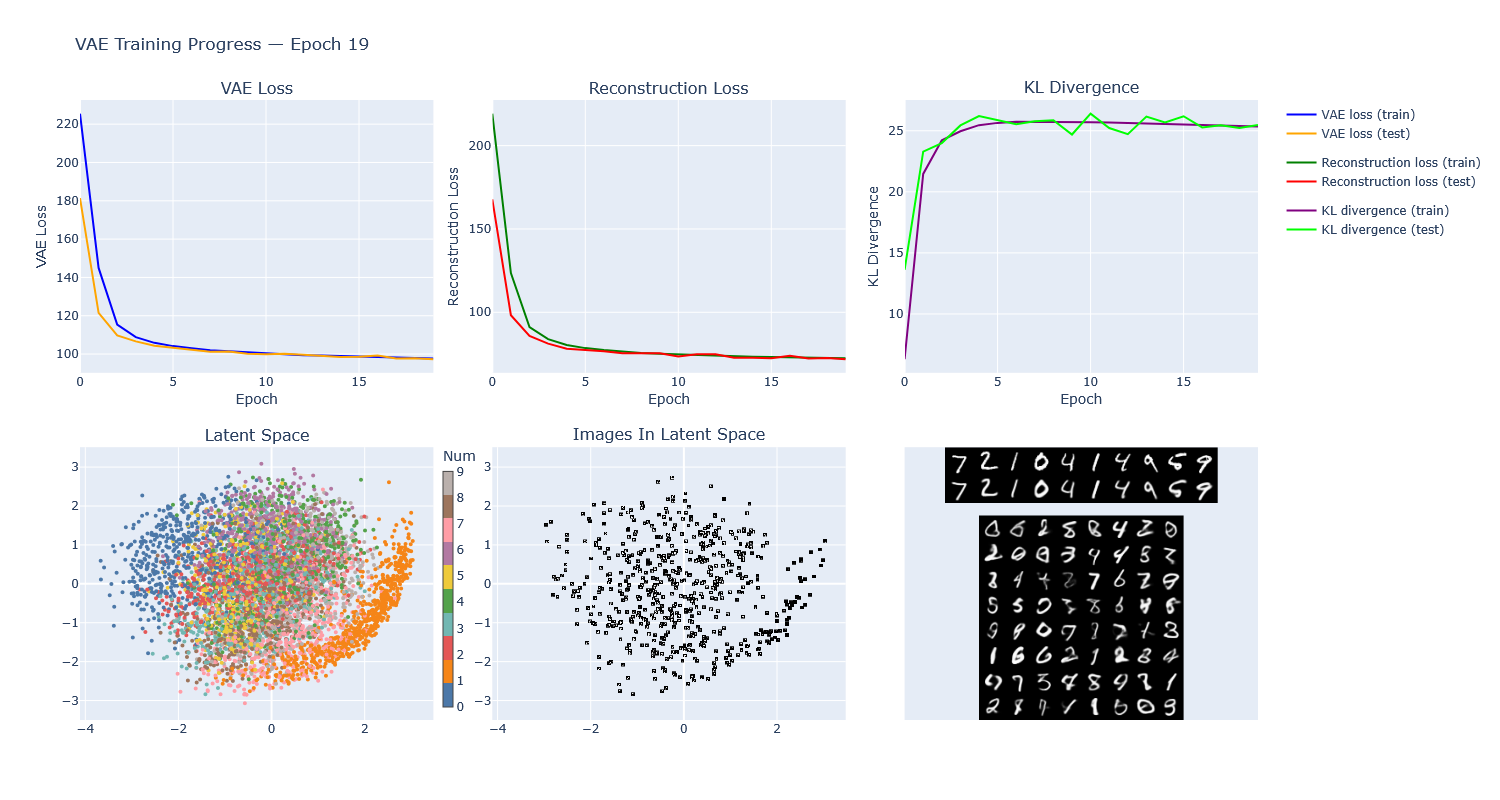

In [ ]:
train_test_model(train_loader, test_loader, model, optimizer, VAE_loss_function, 20, beta, "vae3")

FigureWidget({
    'data': [{'legendgroup': '1',
              'line': {'color': 'blue'},
              'name': 'VAE loss (train)',
              'type': 'scatter',
              'uid': 'a450c49d-1d65-4613-8d3b-3b97276697b5',
              'xaxis': 'x',
              'yaxis': 'y'},
             {'legendgroup': '1',
              'line': {'color': 'orange'},
              'name': 'VAE loss (test)',
              'type': 'scatter',
              'uid': '464f7ca6-158a-4f2b-8bc7-7653553b919c',
              'xaxis': 'x',
              'yaxis': 'y'},
             {'legendgroup': '2',
              'line': {'color': 'green'},
              'name': 'Reconstruction loss (train)',
              'type': 'scatter',
              'uid': '72ea8eec-49fd-4f22-8254-b881ba15d518',
              'xaxis': 'x2',
              'yaxis': 'y2'},
             {'legendgroup': '2',
              'line': {'color': 'red'},
              'name': 'Reconstruction loss (test)',
              'type': 'scatter',
       

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 0 train:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 0 test:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1 train:   0%|          | 0/235 [00:00<?, ?it/s]

KeyboardInterrupt: 

### Оценка модели

(np.float64(-0.5), np.float64(301.5), np.float64(61.5), np.float64(-0.5))

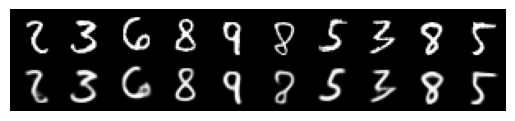

In [ ]:
plt.imshow(visualize_reconstructions(test_loader, model).permute(1, 2, 0))
plt.grid(False)
plt.axis("off")

(np.float64(-0.5), np.float64(241.5), np.float64(241.5), np.float64(-0.5))

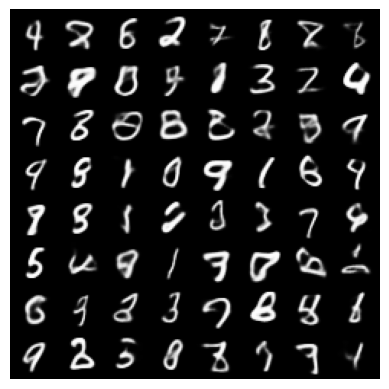

In [ ]:
plt.imshow(generate_sample(model, 64).permute(1, 2, 0))
plt.grid(False)
plt.axis("off")

Модель LeNet для использования в FID

In [ ]:
class LeNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 120),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
        )
        self.seq2 = nn.Sequential(
            nn.Linear(84,10),
            nn.Sigmoid()
        )

    def forward(self, x, get_features=False):
        step1 = self.seq1(x)
        if get_features:
          return step1
        return self.seq2(step1)

In [ ]:
def train_lenet(data_loader, model, optimizer, loss_function, num_epoch, model_title="lenet"):
      # Обучение в течение одной эпохи
      epoch_loss = 0

      for x, labels in tqdm(data_loader, desc=f"Epoch {num_epoch} train", leave=False):
          optimizer.zero_grad()
          result = model(x)
          loss = loss_function(result, labels)

          loss.backward()
          optimizer.step()
          epoch_loss += loss.item()

      save_model_state(model, optimizer, model_title, num_epoch)
      return epoch_loss / len(iter(data_loader))


def test_lenet(data_loader, model, loss_function, num_epoch):
      # Тест в течение одной эпохи
      epoch_loss = 0
      epoch_reconstruction_loss = 0
      epoch_KL_divergence = 0
      model.eval()
      with torch.no_grad():
        for x, labels in tqdm(data_loader, desc=f"Epoch {num_epoch} test", leave=False):
            result = model(x)
            loss = loss_function(result, labels)
            epoch_loss += loss.item()
      return epoch_loss / len(iter(data_loader))


def train_test_lenet(train_loader, test_loader, model, optimizer, loss_function, num_epochs, model_title="lenet"):
    # Процесс обучения модели
    train_loss = []
    test_loss = []

    for epoch in tqdm(range(num_epochs)):
      epoch_train_loss = train_lenet(train_loader, model, optimizer, loss_function, epoch, model_title)
      epoch_test_loss= test_lenet(test_loader, model, loss_function, epoch)

      train_loss.append(epoch_train_loss); test_loss.append(epoch_test_loss)
      print(f"Epoch {epoch} | {epoch_train_loss=} | {epoch_test_loss=}")

    plt.plot(range(num_epochs), train_loss, c="blue", label="train loss")
    plt.plot(range(num_epochs), test_loss, c="orange", label="test loss")
    plt.title("LeNet loss per epoch")
    plt.legend()
    plt.show()


In [ ]:
feature_extractor = LeNet()
feature_extractor_optimizer = torch.optim.Adam(feature_extractor.parameters(), lr=learning_rate)
feature_extractor_loss = nn.CrossEntropyLoss()

In [ ]:
load_model_state(feature_extractor, "lenet", feature_extractor_optimizer)

4

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 0 train:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 0 test:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 0 | epoch_train_loss=1.6893726866295997 | epoch_test_loss=1.532265341281891


Epoch 1 train:   0%|          | 0/235 [00:00<?, ?it/s]

...

Epoch 3 test:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 3 | epoch_train_loss=1.4862334865204831 | epoch_test_loss=1.4819751650094986


Epoch 4 train:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 4 test:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 4 | epoch_train_loss=1.4816237779373818 | epoch_test_loss=1.477142834663391


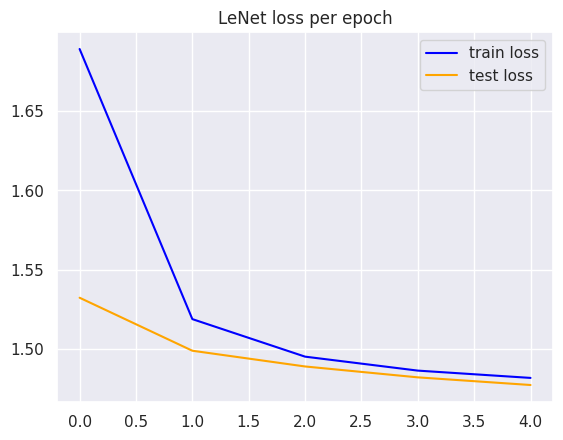

In [ ]:
train_test_lenet(train_loader, test_loader, feature_extractor, feature_extractor_optimizer, feature_extractor_loss, 5, model_title="lenet")

Подсчет FID

In [ ]:
def calculate_fid(real_images, fake_images, feature_extractor, model):
    # расчет метрики FID
    if isinstance(model, nn.Module):
      model.eval()
    real_features = feature_extractor(real_images, get_features=True).flatten(start_dim=1)
    fake_features = feature_extractor(fake_images, get_features=True).flatten(start_dim=1)

    mu_real, sigma_real = real_features.mean(dim=0), torch.cov(real_features.T)
    mu_fake, sigma_fake = fake_features.mean(dim=0), torch.cov(fake_features.T)

    diff = mu_real - mu_fake
    covmean = scipy.linalg.sqrtm((sigma_real @ sigma_fake).detach().numpy())
    fid = diff.dot(diff) + torch.trace(sigma_real + sigma_fake - 2 * torch.tensor(covmean.real))
    return fid.item()

In [ ]:
real_images = next(iter(test_loader))[0]
fake_images = model.decode(torch.randn(len(real_images), model.latent_dim))

In [ ]:
calculate_fid(real_images, fake_images, feature_extractor, model)

288.1220703125

### Использование сторонней модели

In [ ]:
from huggingface_hub import from_pretrained_keras
import tensorflow as tf

hf_model = from_pretrained_keras("Maksimk04/Digits_autoencoder_mnist")

Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
hf_model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 784)]             0         
                                                                 
 encoder (Functional)        (None, 3)                 124233    
                                                                 
 decoder (Functional)        (None, 784)               125014    
                                                                 
Total params: 249247 (973.62 KB)
Trainable params: 249247 (973.62 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
latent_vectors = tf.convert_to_tensor(np.random.randn(batch_size, 28 * 28).astype(np.float32))
generated_images = hf_model(latent_vectors).numpy()
generated_images = torch.tensor(generated_images).view(-1, 1, 28, 28).to(device)

(np.float64(-0.5), np.float64(301.5), np.float64(61.5), np.float64(-0.5))

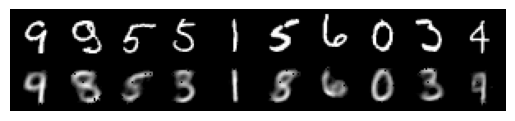

In [ ]:
data = tf.convert_to_tensor(next(iter(test_loader))[0].reshape(-1, 28 * 28))
reconstruction = hf_model(data)
n = 10
ix = np.random.choice(range(len(data) - n))
comparison = torch.cat([
    torch.Tensor(data[ix:ix+n].numpy().reshape(-1, 1, 28, 28)),
    torch.Tensor(reconstruction[ix:ix+n].numpy().reshape(-1, 1, 28, 28))
])
plt.imshow(make_grid(comparison, nrow=n).permute(1, 2, 0))
plt.grid(False)
plt.axis("off")

(np.float64(-0.5), np.float64(241.5), np.float64(241.5), np.float64(-0.5))

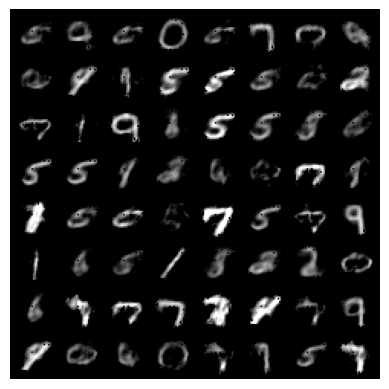

In [ ]:
plt.imshow(make_grid(generated_images[:64], nrow=8).permute(1, 2, 0))
plt.grid(False)
plt.axis("off")

In [ ]:
calculate_fid(real_images, generated_images, feature_extractor, hf_model)

1740.7037353515625

### CVAE

In [ ]:
class CVAE(nn.Module):
    def __init__(self, latent_dim=20, num_classes=10):
        super(CVAE, self).__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes

        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.Flatten()
        )

        self.encoder_fc_input_dim = 64 * 7 * 7 + num_classes
        self.fc_mu = nn.Linear(self.encoder_fc_input_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.encoder_fc_input_dim, latent_dim)

        self.decoder_fc_input = latent_dim + num_classes
        self.decoder = nn.Sequential(
            nn.Linear(self.decoder_fc_input, 64 * 7 * 7),
            nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(64, 64, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def one_hot(self, labels):
        return F.one_hot(labels, num_classes=self.num_classes).float()

    def encode(self, x, y):
        h = self.encoder_conv(x)
        y_onehot = self.one_hot(y)
        h_concat = torch.cat([h, y_onehot], dim=1)
        mu = self.fc_mu(h_concat)
        logvar = self.fc_logvar(h_concat)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, y):
        y_onehot = self.one_hot(y)
        z_concat = torch.cat([z, y_onehot], dim=1)
        return self.decoder(z_concat)

    def forward(self, x, y):
        mu, logvar = self.encode(x, y)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z, y)
        return recon, mu, logvar


In [ ]:
class CVAE(nn.Module):
    def __init__(self, latent_dim=10, num_classes=10):
        super(CVAE, self).__init__()

        self.num_classes = num_classes
        self.latent_dim = latent_dim

        # Кодировщик
        self.encoder = nn.Sequential(
            nn.Conv2d(1 + num_classes, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(3136, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim*2)
        )

        # Декодировщик
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + num_classes, 256),
            nn.ReLU(),
            nn.Linear(256, 64*7*7),
            nn.ReLU(),
            nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, labels):
        labels_onehot = torch.zeros(x.size(0), self.num_classes).to(device)
        labels_onehot.scatter_(1, labels.view(-1, 1), 1)

        x = torch.cat([x, labels_onehot.view(labels_onehot.size(0), self.num_classes, 1, 1).expand(-1, -1, 28, 28)], dim=1)

        x = self.encoder(x)
        mu, log_var = x[:, :self.latent_dim], x[:, self.latent_dim:]
        z = self.reparameterize(mu, log_var)

        z = torch.cat([z, labels_onehot], dim=1)
        x_reconstructed = self.decoder(z)
        return x_reconstructed, mu, log_var

    def sample(self, num_samples, labels):
        labels_onehot = torch.zeros(num_samples, self.num_classes).to(device)
        labels_onehot.scatter_(1, labels.view(-1, 1), 1)
        z = torch.randn((num_samples, self.latent_dim)).to(device)
        z = torch.cat([z, labels_onehot], dim=1)
        generated_images = self.decoder(z)
        return generated_images


In [ ]:
cvae_model = CVAE(latent_dim, 10).to(device)
cvae_optimizer = torch.optim.Adam(cvae_model.parameters(), lr=learning_rate)

In [ ]:
def train_cvae(data_loader, model, optimizer, loss_function, num_epoch, beta=1, model_title="vae"):
      # Обучение в течение одной эпохи
      epoch_loss = 0
      epoch_reconstruction_loss = 0
      epoch_KL_divergence = 0

      all_mus = []
      all_labels = []
      all_images = []

      for x, labels in tqdm(data_loader, desc=f"Epoch {num_epoch} train", leave=False):
          optimizer.zero_grad()
          x_reconstructed, mu, log_var = model(x, labels)
          loss, reconstruction_loss, KL_divergence = loss_function(x, x_reconstructed, mu, log_var, beta)

          loss.backward()
          optimizer.step()

          epoch_loss += loss.item()
          epoch_reconstruction_loss += reconstruction_loss.item()
          epoch_KL_divergence += KL_divergence.item()

          all_mus.append(mu.detach().numpy())
          all_labels.append(labels.numpy())
          all_images.append(x_reconstructed.detach().numpy())

      all_mus = np.concat(all_mus, axis=0)
      all_labels = np.concat(all_labels, axis=0)
      all_images = np.concat(all_images, axis=0)

      latent_space, labels, images = get_latent_space_sample(all_mus, all_labels, all_images, 0.1)

      save_model_state(model, optimizer, model_title, num_epoch)

      return epoch_loss / len(data_loader.dataset), epoch_reconstruction_loss / len(data_loader.dataset), epoch_KL_divergence / len(data_loader.dataset), latent_space, labels, images

In [ ]:
def test_cvae(data_loader, model, loss_function, num_epoch, beta=1):
      # Тест в течение одной эпохи
      epoch_loss = 0
      epoch_reconstruction_loss = 0
      epoch_KL_divergence = 0
      model.eval()
      with torch.no_grad():
        for x, labels in tqdm(data_loader, desc=f"Epoch {num_epoch} test", leave=False):
            x_reconstructed, mu, log_var = model(x, labels)
            loss, reconstruction_loss, KL_divergence = loss_function(x, x_reconstructed, mu, log_var, beta)

            epoch_loss += loss.item()
            epoch_reconstruction_loss += reconstruction_loss.item()
            epoch_KL_divergence += KL_divergence.item()

      return epoch_loss / len(data_loader.dataset), epoch_reconstruction_loss / len(data_loader.dataset), epoch_KL_divergence / len(data_loader.dataset)

In [ ]:
def train_test_model_cvae(train_loader, test_loader, model, optimizer, loss_function, num_epochs, beta=1, model_title="vae"):
    # Процесс обучения модели
    train_loss, train_rec_loss, train_KL_div = [], [], []
    test_loss, test_rec_loss, test_KL_div = [], [], []

    fig_widget = create_plot_widget()
    display(fig_widget)

    for epoch in tqdm(range(num_epochs)):
      epoch_train_loss, epoch_train_rec_loss, epoch_train_KL_div, latent_space, latent_space_labels, images = train_cvae(train_loader, model, optimizer, loss_function, epoch, beta, model_title)
      epoch_test_loss, epoch_test_rec_loss, epoch_test_KL_div = test_cvae(test_loader, model, loss_function, epoch, beta)

      train_loss.append(epoch_train_loss); test_loss.append(epoch_test_loss)
      train_rec_loss.append(epoch_train_rec_loss); test_rec_loss.append(epoch_test_rec_loss)
      train_KL_div.append(epoch_train_KL_div); test_KL_div.append(epoch_test_KL_div)

      update_plot_widget(fig_widget, train_loss, test_loss, train_rec_loss, test_rec_loss, train_KL_div, test_KL_div,
                         latent_space, latent_space_labels, images, 0.1, None, None)

In [ ]:
train_test_model_cvae(train_loader, test_loader, cvae_model, cvae_optimizer, VAE_loss_function, 20, beta, "cvae")

FigureWidget({
    'data': [{'legendgroup': '1',
              'line': {'color': 'blue'},
              'name': 'VAE loss (train)',
              'type': 'scatter',
              'uid': '281d67c9-156f-4c60-a3d3-afb2a456da87',
              'xaxis': 'x',
              'yaxis': 'y'},
             {'legendgroup': '1',
              'line': {'color': 'orange'},
              'name': 'VAE loss (test)',
              'type': 'scatter',
              'uid': '049f354c-29fe-48a2-91c1-40d2bd00aae9',
              'xaxis': 'x',
              'yaxis': 'y'},
             {'legendgroup': '2',
              'line': {'color': 'green'},
              'name': 'Reconstruction loss (train)',
              'type': 'scatter',
              'uid': '7dfc6ada-a204-42a4-91e3-984de46f7bc1',
              'xaxis': 'x2',
              'yaxis': 'y2'},
             {'legendgroup': '2',
              'line': {'color': 'red'},
              'name': 'Reconstruction loss (test)',
              'type': 'scatter',
       

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 0 train:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 0 test:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1 train:   0%|          | 0/235 [00:00<?, ?it/s]

...

Epoch 10 test:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 11 train:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 11 test:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 12 train:   0%|          | 0/235 [00:00<?, ?it/s]

KeyboardInterrupt: 

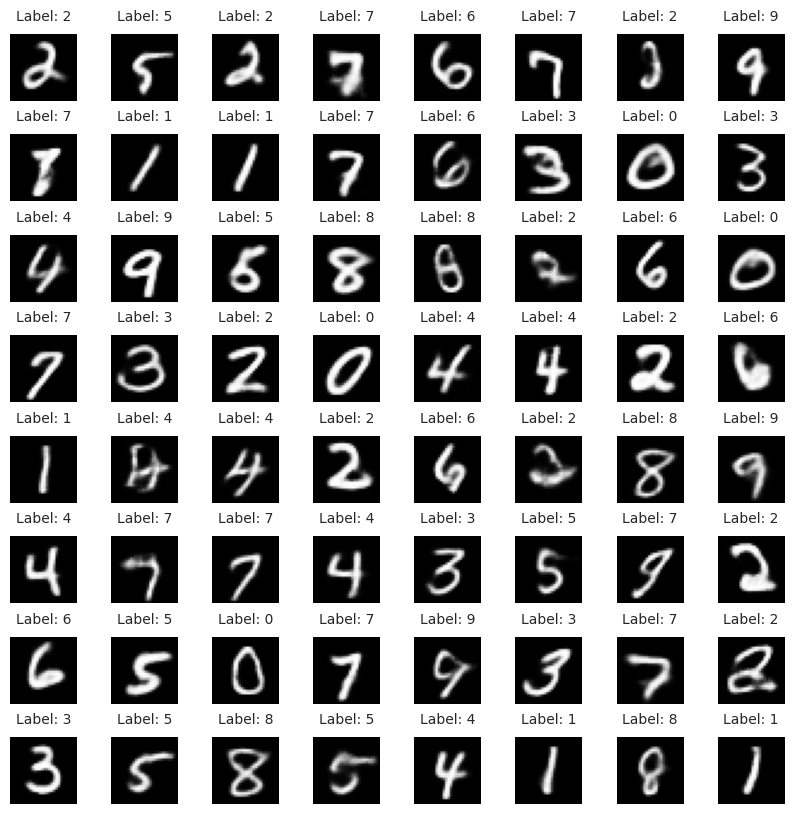

In [ ]:
import matplotlib.pyplot as plt

with torch.no_grad():
    num_samples = 64
    labels = torch.randint(0, 10, (num_samples,)).to(device)
    generated_images = cvae_model.sample(num_samples, labels)
    generated_images = generated_images.cpu().numpy()

    fig, axes = plt.subplots(8, 8, figsize=(10, 10))
    for i in range(8):
        for j in range(8):
            idx = i * 8 + j
            axes[i, j].imshow(generated_images[idx].reshape(28, 28), cmap="gray")
            axes[i, j].axis("off")
            # Увеличиваем размер шрифта и делаем отступы
            axes[i, j].set_title(f"Label: {labels[idx].item()}", fontsize=10, pad=10)

    plt.subplots_adjust(wspace=0.5, hspace=0.5)
    plt.show()


In [ ]:
# real_images, real_labels = next(iter(trainloader))
# real_images = real_images[real_labels == 1].to(device)

# real_features = get_features(real_images, lenet)
# mu_real, sigma_real = real_features.mean(dim=0), torch.cov(real_features.T)

# labels = torch.full((num_samples,), 1, device=device)
# generated_images = autoencoder.sample(num_samples, labels).to(device)

# # Получаем фичи для сгенерированных двоек
# gen_features = get_features(generated_images, lenet)
# mu_gen, sigma_gen = gen_features.mean(dim=0), torch.cov(gen_features.T)

# # Вычисляем FID
# fid_value = calculate_fid(mu_real, sigma_real, mu_gen, sigma_gen)
# print(f"FID для едиинц: {fid_value.item()}")
